# Artefato A05 - CNN Simples

Este notebook foi reconstruído para funcionar como **artefato principal**, e não apenas como consolidação de evidências.
Ele reúne, em um único fluxo:

1. preparação dos dados para a CNN;
2. implementação explícita da arquitetura convolucional;
3. treinamento e validação do baseline original;
4. avaliação quantitativa com comparação ao baseline MLP da Sprint 2;
5. ampliação final por sensor para Sentinel-2, Landsat 8/9 e MODIS;
6. análise crítica consolidada.

A renderização abaixo preserva os outputs já salvos em `outputs/`, mas as células principais agora trazem o código consolidado dentro do próprio artefato.

## 1) Setup e carregamento dos artefatos

O notebook foi preparado para duas situações:

- **revisão**: carregar os artefatos já gerados e mostrar todo o processo com outputs embutidos;
- **reexecução**: quando `TensorFlow` e os dados brutos estiverem disponíveis, as células principais podem ser reativadas para reproduzir preparação e treino.

In [1]:
from pathlib import Path
import json
import os
import re

os.environ.setdefault("MPLCONFIGDIR", str((Path.cwd() / ".mplconfig").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
except Exception:
    sns = None

try:
    from IPython.display import Markdown, display
except Exception:
    def display(obj):
        print(obj)

    def Markdown(text):
        return text


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "src").exists():
        return cwd
    for parent in [cwd, *cwd.parents]:
        if (parent / "src").exists():
            return parent
    raise FileNotFoundError("Não foi possível localizar a raiz do projeto.")


PROJECT_ROOT = resolve_project_root()
ARTEFATO_DIR = PROJECT_ROOT / "artefatos" / "a05_cnn_simples"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FINAL_OUTPUTS_DIR = OUTPUTS_DIR / "final"
FINAL_CNN_DIR = FINAL_OUTPUTS_DIR / "a05_cnn_multissatelite"

SENSOR_ORDER = ["sentinel2", "landsat89", "modis"]
SENSOR_NAMES = {
    "sentinel2": "Sentinel-2",
    "landsat89": "Landsat 8/9",
    "modis": "MODIS",
}

if sns is not None:
    sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import Sequential, layers, regularizers
    TF_AVAILABLE = True
except Exception as exc:
    TF_AVAILABLE = False
    TF_IMPORT_ERROR = str(exc)


def read_json(path: Path) -> dict:
    with path.open("r", encoding="utf-8") as fp:
        return json.load(fp)


def read_csv(path: Path) -> pd.DataFrame:
    return pd.read_csv(path)


def read_lines(path: Path) -> list[str]:
    return [line.strip() for line in path.read_text(encoding="utf-8").splitlines() if line.strip()]


def collect_output_text(cell: dict) -> str:
    parts = []
    for output in cell.get("outputs", []):
        if output.get("output_type") == "stream":
            text = output.get("text", "")
            if isinstance(text, list):
                text = "".join(text)
            parts.append(text)
        elif output.get("output_type") in {"execute_result", "display_data"}:
            data = output.get("data", {})
            text = data.get("text/plain", "")
            if isinstance(text, list):
                text = "".join(text)
            parts.append(text)
    return "\n".join(parts)


def load_notebook(rel_path: str) -> dict:
    return read_json(PROJECT_ROOT / rel_path)


def parse_mlp_artifact(rel_path: str) -> dict:
    notebook = load_notebook(rel_path)
    parsed = {
        "test_output": "",
        "confusion_text": "",
        "report_text": "",
        "confusion_matrix": np.array([[np.nan, np.nan], [np.nan, np.nan]]),
    }
    for cell in notebook.get("cells", []):
        if cell.get("cell_type") != "code":
            continue
        text = collect_output_text(cell)
        if not parsed["test_output"] and "Resultados no teste" in text:
            parsed["test_output"] = text.strip()
        if not parsed["confusion_text"] and "Matriz de Confus" in text:
            parsed["confusion_text"] = text.strip()
        if not parsed["report_text"] and "Relatório de Classificação" in text:
            parsed["report_text"] = text.strip()

    numbers = [int(value) for value in re.findall(r"-?\d+", parsed["confusion_text"])]
    if len(numbers) >= 4:
        parsed["confusion_matrix"] = np.array(numbers[-4:]).reshape(2, 2)
    return parsed


def metrics_from_confusion(matrix: np.ndarray) -> dict:
    tn, fp, fn, tp = matrix.ravel()
    accuracy = (tp + tn) / matrix.sum()
    precision_pos = tp / (tp + fp) if (tp + fp) else 0.0
    recall_pos = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    f1_pos = 2 * precision_pos * recall_pos / (precision_pos + recall_pos) if (precision_pos + recall_pos) else 0.0
    return {
        "accuracy": accuracy,
        "precision_positiva": precision_pos,
        "recall_positivo": recall_pos,
        "f1_positivo": f1_pos,
        "specificity": specificity,
        "support_negativo": int(tn + fp),
        "support_positivo": int(tp + fn),
    }


def plot_confusion(ax, matrix, title: str) -> None:
    labels = ["Negativo", "Positivo"]
    matrix = np.asarray(matrix)
    if sns is not None:
        sns.heatmap(
            matrix,
            annot=True,
            fmt=".0f",
            cmap="Blues",
            cbar=False,
            xticklabels=labels,
            yticklabels=labels,
            ax=ax,
        )
    else:
        im = ax.imshow(matrix, cmap="Blues")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        for row in range(matrix.shape[0]):
            for col in range(matrix.shape[1]):
                ax.text(col, row, int(matrix[row, col]), ha="center", va="center")
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels)
        ax.set_yticks(range(len(labels)))
        ax.set_yticklabels(labels)
    ax.set_title(title)
    ax.set_xlabel("Predito")
    ax.set_ylabel("Real")


def load_sensor_bundle(sensor_key: str) -> dict:
    sensor_dir = FINAL_CNN_DIR / sensor_key
    return {
        "sensor_key": sensor_key,
        "sensor_name": SENSOR_NAMES[sensor_key],
        "overview": read_json(FINAL_OUTPUTS_DIR / f"{sensor_key}_overview.json"),
        "band_summary": read_csv(FINAL_OUTPUTS_DIR / f"{sensor_key}_band_summary.csv"),
        "index_summary": read_csv(FINAL_OUTPUTS_DIR / f"{sensor_key}_index_summary.csv"),
        "image_counts": read_csv(FINAL_OUTPUTS_DIR / f"{sensor_key}_image_counts.csv"),
        "hypotheses": read_lines(FINAL_OUTPUTS_DIR / f"{sensor_key}_hypotheses.txt"),
        "data_prep": read_json(sensor_dir / "data_prep_summary.json"),
        "architecture": read_json(sensor_dir / "architecture_summary.json"),
        "split": read_json(sensor_dir / "split_summary.json"),
        "history": read_json(sensor_dir / "history.json"),
        "history_df": read_csv(sensor_dir / "history.csv"),
        "metrics": read_json(sensor_dir / "metrics_test.json"),
        "confusion": read_csv(sensor_dir / "confusion_matrix.csv"),
    }


cnn_prep_summary = read_json(OUTPUTS_DIR / "a04_cnn_data_prep" / "cnn_data_prep_summary.json")
baseline_summary = read_json(OUTPUTS_DIR / "a06_avaliacao_experimental" / "e1_baseline_summary.json")
baseline_history = read_json(OUTPUTS_DIR / "trained_models" / "baseline_20260311_083736" / "history.json")
experiments_log = read_csv(OUTPUTS_DIR / "trained_models" / "experiments_log.csv")
mlp_metrics = read_json(OUTPUTS_DIR / "a03_mlp_baseline" / "mlp_baseline_metrics.json")
mlp_artifact = parse_mlp_artifact("artefatos/a03_mlp_baseline/a03_mlp_baseline.ipynb")
compiled_overview_df = read_csv(FINAL_OUTPUTS_DIR / "compilado_overview.csv")
compiled_hypotheses = read_lines(FINAL_OUTPUTS_DIR / "compilado_hipoteses.txt")
final_comparison_df = read_csv(FINAL_CNN_DIR / "cnn_multissatelite_comparison.csv")
final_analysis_lines = read_lines(FINAL_CNN_DIR / "cnn_multissatelite_analysis.txt")
artifacts = {sensor_key: load_sensor_bundle(sensor_key) for sensor_key in SENSOR_ORDER}

baseline_cm = np.array(
    [
        [baseline_summary["confusion_matrix"]["TN"], baseline_summary["confusion_matrix"]["FP"]],
        [baseline_summary["confusion_matrix"]["FN"], baseline_summary["confusion_matrix"]["TP"]],
    ]
)
mlp_cm = mlp_artifact["confusion_matrix"]

setup_df = pd.DataFrame(
    [
        {"arquivo": "artefatos/a05_cnn_simples/a05_cnn_simples.ipynb", "existe": (ARTEFATO_DIR / "a05_cnn_simples.ipynb").exists()},
        {"arquivo": "src/models/cnn_data_prep.py", "existe": (PROJECT_ROOT / "src/models/cnn_data_prep.py").exists()},
        {"arquivo": "src/models/cnn_builder.py", "existe": (PROJECT_ROOT / "src/models/cnn_builder.py").exists()},
        {"arquivo": "src/models/experiment_runner.py", "existe": (PROJECT_ROOT / "src/models/experiment_runner.py").exists()},
        {"arquivo": "outputs/a06_avaliacao_experimental/e1_baseline_summary.json", "existe": (OUTPUTS_DIR / "a06_avaliacao_experimental/e1_baseline_summary.json").exists()},
        {"arquivo": "outputs/final/a05_cnn_multissatelite/cnn_multissatelite_comparison.csv", "existe": (FINAL_CNN_DIR / "cnn_multissatelite_comparison.csv").exists()},
    ]
)
display(setup_df)
if TF_AVAILABLE:
    print("TensorFlow disponível para reexecução local.")
else:
    print(f"TensorFlow indisponível neste ambiente: {TF_IMPORT_ERROR}")
print(f"Projeto: {PROJECT_ROOT}")

TensorFlow indisponível neste ambiente: No module named 'tensorflow'
Projeto: /Users/giovanna-britto/Documents/INTELI/PROJETO/g01


,arquivo,existe
0,artefatos/a05_cnn_simples/a05_cnn_simples.ipynb,True
1,src/models/cnn_data_prep.py,True
2,src/models/cnn_builder.py,True
3,src/models/experiment_runner.py,True
4,outputs/a06_avaliacao_experimental/e1_baseline...,True
5,outputs/final/a05_cnn_multissatelite/cnn_multi...,True


## 2) Escopo, fontes e critério de consolidação

O notebook final usa o código-fonte do projeto como base de implementação e utiliza os notebooks anteriores apenas como referência histórica. Em outras palavras:

- a **implementação principal** aparece diretamente neste notebook;
- os **artefatos salvos** em `outputs/` entram como evidência reprodutível;
- a **ampliação final por sensor** foi incorporada ao mesmo fluxo para mostrar a evolução do baseline CNN.

In [2]:
source_df = pd.DataFrame(
    [
        {"componente": "Preparação dos dados", "origem": "src/models/cnn_data_prep.py + notebooks/cnn_preparacao_dados.ipynb", "papel": "Conversão para tensores 4D, z-score por canal e split estratificado."},
        {"componente": "Arquitetura CNN", "origem": "src/models/cnn_builder.py + notebooks/a05_cnn_teste.ipynb", "papel": "Definição explícita da CNN simples com Conv2D, pooling, flatten e dense."},
        {"componente": "Treinamento", "origem": "src/models/experiment_runner.py + notebooks/a05b_cnn_experiments.ipynb", "papel": "Treino, histórico por época, logging e comparação entre configurações."},
        {"componente": "Avaliação final por sensor", "origem": "notebooks/final/a05_cnn_simples_processo_completo.ipynb + outputs/final/", "papel": "Comparação multissatélite e análise crítica consolidada."},
    ]
)
display(source_df)

,componente,origem,papel
0,Preparação dos dados,src/models/cnn_data_prep.py + notebooks/cnn_pr...,"Conversão para tensores 4D, z-score por canal ..."
1,Arquitetura CNN,src/models/cnn_builder.py + notebooks/a05_cnn_...,"Definição explícita da CNN simples com Conv2D,..."
2,Treinamento,src/models/experiment_runner.py + notebooks/a0...,"Treino, histórico por época, logging e compara..."
3,Avaliação final por sensor,notebooks/final/a05_cnn_simples_processo_compl...,Comparação multissatélite e análise crítica co...


## 3) Preparação dos dados para a CNN

Esta seção traz o código principal da preparação de dados para o baseline original do A05. O fluxo preserva as decisões técnicas centrais do projeto:

- tensores no formato `(N, H, W, C)`;
- cada banda espectral como um canal;
- normalização `z-score` por canal;
- ajuste do normalizador apenas no treino;
- reutilização do mesmo normalizador em validação e teste;
- remoção de rótulos inválidos antes do treino.

In [3]:
import sys

src_path = PROJECT_ROOT / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from models.cnn_data_prep import prepare_cnn_inputs

SEED = 42
DATASET_PATH = PROJECT_ROOT / "data" / "pixels_dataset.csv"
CODES_PATH = PROJECT_ROOT / "data" / "extracted_codes.json"
NORMALIZER_PATH = PROJECT_ROOT / "outputs" / "a04_cnn_data_prep" / "cnn_normalizer_zscore.npz"

RUN_PREP_FROM_RAW = False
SAMPLE_SIZE = 1500


def rebuild_original_cnn_inputs(sample_size: int = 1500) -> dict:
    from sklearn.model_selection import train_test_split

    df = pd.read_csv(DATASET_PATH)
    df = df.sample(n=min(sample_size, len(df)), random_state=SEED).reset_index(drop=True)

    probe = prepare_cnn_inputs(
        df,
        extracted_codes_path=CODES_PATH,
        normalization="none",
        data_format="channels_last",
        drop_invalid_labels=False,
    )

    y_all = probe["y"]
    valid_mask = y_all != -1
    df_valid = df.loc[valid_mask].reset_index(drop=True)
    y_valid = y_all[valid_mask]

    idx = np.arange(len(df_valid))
    train_idx, temp_idx, y_train, y_temp = train_test_split(
        idx,
        y_valid,
        test_size=0.30,
        random_state=SEED,
        stratify=y_valid,
    )
    val_idx, test_idx, y_val, y_test = train_test_split(
        temp_idx,
        y_temp,
        test_size=0.50,
        random_state=SEED,
        stratify=y_temp,
    )

    df_train = df_valid.iloc[train_idx].reset_index(drop=True)
    df_val = df_valid.iloc[val_idx].reset_index(drop=True)
    df_test = df_valid.iloc[test_idx].reset_index(drop=True)

    train_out = prepare_cnn_inputs(
        df_train,
        labels=y_train,
        normalization="zscore",
        data_format="channels_last",
    )
    val_out = prepare_cnn_inputs(
        df_val,
        labels=y_val,
        normalization="zscore",
        normalizer=train_out["normalizer"],
        data_format="channels_last",
    )
    test_out = prepare_cnn_inputs(
        df_test,
        labels=y_test,
        normalization="zscore",
        normalizer=train_out["normalizer"],
        data_format="channels_last",
    )

    return {
        "X_train": train_out["X"],
        "y_train": train_out["y"],
        "X_val": val_out["X"],
        "y_val": val_out["y"],
        "X_test": test_out["X"],
        "y_test": test_out["y"],
        "normalizer": train_out["normalizer"],
        "shape_info": train_out["shape_info"],
    }


original_data = None
if RUN_PREP_FROM_RAW and DATASET_PATH.exists() and CODES_PATH.exists():
    original_data = rebuild_original_cnn_inputs(sample_size=SAMPLE_SIZE)
    print("Preparação reexecutada a partir dos dados brutos.")
else:
    print("Preparação documentada com código direto e evidenciada pelos artefatos salvos.")

Preparação documentada com código direto e evidenciada pelos artefatos salvos.


In [4]:
normalizer_npz = np.load(NORMALIZER_PATH)
normalizer_mean = np.asarray(normalizer_npz["mean"]).reshape(-1)
normalizer_std = np.asarray(normalizer_npz["std"]).reshape(-1)

prep_decisions_df = pd.DataFrame(
    [
        {"decisão": "Formato do tensor", "valor": "(N, H, W, C)", "justificativa": "Compatível com Conv2D em channels_last."},
        {"decisão": "Entrada base", "valor": f"({cnn_prep_summary['height']}, {cnn_prep_summary['width']}, {cnn_prep_summary['n_channels']})", "justificativa": "Preserva a estrutura espacial do chip e as 9 bandas."},
        {"decisão": "Normalização", "valor": cnn_prep_summary["normalization"], "justificativa": "Padroniza as bandas por canal e reduz diferenças de escala."},
        {"decisão": "Controle de vazamento", "valor": "normalizador ajustado no treino", "justificativa": "As estatísticas do treino são reaplicadas em validação e teste."},
        {"decisão": "Split", "valor": f"{cnn_prep_summary['n_train']}/{cnn_prep_summary['n_val']}/{cnn_prep_summary['n_test']}", "justificativa": "Separação estratificada para treino, validação e teste."},
    ]
)
display(prep_decisions_df)

split_df = pd.DataFrame(
    [
        {
            "dataset_origem": Path(cnn_prep_summary["dataset_path"]).name,
            "sample_size": cnn_prep_summary["sample_size"],
            "n_train": cnn_prep_summary["n_train"],
            "n_val": cnn_prep_summary["n_val"],
            "n_test": cnn_prep_summary["n_test"],
        }
    ]
)
display(split_df)

train_balance_df = (
    pd.Series(cnn_prep_summary["train_class_balance"], name="n_amostras")
    .rename_axis("classe")
    .reset_index()
)
display(train_balance_df)

normalizer_df = pd.DataFrame(
    {
        "canal": [f"canal_{idx + 1}" for idx in range(len(normalizer_mean))],
        "média_treino": np.round(normalizer_mean, 4),
        "desvio_treino": np.round(normalizer_std, 4),
    }
)
display(normalizer_df)

if original_data is not None:
    rebuilt_df = pd.DataFrame(
        [
            {
                "X_train": original_data["X_train"].shape,
                "X_val": original_data["X_val"].shape,
                "X_test": original_data["X_test"].shape,
                "y_train": original_data["y_train"].shape,
            }
        ]
    )
    display(rebuilt_df)

display(
    Markdown(
        f'''
        **Leitura desta etapa**

        - O baseline CNN do A05 trabalha com entrada espacial `{cnn_prep_summary['height']}x{cnn_prep_summary['width']}` e `{cnn_prep_summary['n_channels']}` canais.
        - O normalizador foi salvo em `outputs/a04_cnn_data_prep/cnn_normalizer_zscore.npz`, o que permite rastrear exatamente a normalização usada no experimento.
        - O código acima já está consolidado neste notebook; quando `RUN_PREP_FROM_RAW = True`, a preparação pode ser reexecutada localmente.
        '''
    )
)

,decisão,valor,justificativa
0,Formato do tensor,"(N, H, W, C)",Compatível com Conv2D em channels_last.
1,Entrada base,"(128, 128, 9)",Preserva a estrutura espacial do chip e as 9 b...
2,Normalização,zscore,Padroniza as bandas por canal e reduz diferenç...
3,Controle de vazamento,normalizador ajustado no treino,As estatísticas do treino são reaplicadas em v...
4,Split,206/44/45,"Separação estratificada para treino, validação..."


,dataset_origem,sample_size,n_train,n_val,n_test
0,pixels_dataset.csv,1500,206,44,45


,classe,n_amostras
0,0,125
1,1,81


,canal,média_treino,desvio_treino
0,canal_1,53.378502,48.180401
1,canal_2,54.231701,56.785500
2,canal_3,149.128601,93.082199
3,canal_4,202.774994,115.582100
4,canal_5,132.054993,79.339500
5,canal_6,125.841103,76.659500
6,canal_7,119.787697,73.474899
7,canal_8,85.050400,54.237499
8,canal_9,65.441498,40.502998



        **Leitura desta etapa**

        - O baseline CNN do A05 trabalha com entrada espacial `128x128` e `9` canais.
        - O normalizador foi salvo em `outputs/a04_cnn_data_prep/cnn_normalizer_zscore.npz`, o que permite rastrear exatamente a normalização usada no experimento.
        - O código acima já está consolidado neste notebook; quando `RUN_PREP_FROM_RAW = True`, a preparação pode ser reexecutada localmente.
        

## 4) Implementação da arquitetura CNN simples

A arquitetura abaixo é a implementação direta do baseline do A05. O desenho segue:

`Entrada → Conv2D(32) → Dropout → MaxPooling → Conv2D(64) → Dropout → MaxPooling → Flatten → Dense(128) → Dropout → Saída`

In [5]:
BASELINE_MODEL_CONFIG = {
    "input_shape": tuple(baseline_summary["hyperparameters"]["input_shape"]),
    "num_classes": baseline_summary["hyperparameters"]["num_classes"],
    "filters": baseline_summary["hyperparameters"]["filters"],
    "kernel_size": baseline_summary["hyperparameters"]["kernel_size"],
    "pool_size": baseline_summary["hyperparameters"]["pool_size"],
    "dense_units": baseline_summary["hyperparameters"]["dense_units"],
    "conv_dropout_rate": baseline_summary["hyperparameters"]["conv_dropout_rate"],
    "dense_dropout_rate": baseline_summary["hyperparameters"]["dense_dropout_rate"],
    "l2_regularizer": baseline_summary["hyperparameters"]["l2_regularizer"],
    "learning_rate": baseline_summary["hyperparameters"]["learning_rate"],
}

display(pd.DataFrame([BASELINE_MODEL_CONFIG]))

,input_shape,num_classes,filters,kernel_size,pool_size,dense_units,conv_dropout_rate,dense_dropout_rate,l2_regularizer,learning_rate
0,"(128, 128, 9)",2,"[32, 64]",3,2,128,0.2,0.5,0.001,0.001


In [6]:
def build_baseline_cnn(
    input_shape=(128, 128, 9),
    num_classes=2,
    filters=(32, 64),
    kernel_size=(3, 3),
    dense_units=128,
    conv_dropout_rate=0.2,
    dense_dropout_rate=0.5,
    l2_regularizer_value=0.001,
    learning_rate=0.001,
):
    if not TF_AVAILABLE:
        return None

    model = Sequential(
        [
            layers.Input(shape=input_shape),
            layers.Conv2D(
                filters=filters[0],
                kernel_size=kernel_size,
                padding="same",
                activation="relu",
                kernel_regularizer=regularizers.l2(l2_regularizer_value),
                name="conv2d_1",
            ),
            layers.Dropout(conv_dropout_rate, name="dropout_conv1"),
            layers.MaxPooling2D(pool_size=(2, 2), strides=2, name="maxpooling2d_1"),
            layers.Conv2D(
                filters=filters[1],
                kernel_size=kernel_size,
                padding="same",
                activation="relu",
                kernel_regularizer=regularizers.l2(l2_regularizer_value),
                name="conv2d_2",
            ),
            layers.Dropout(conv_dropout_rate, name="dropout_conv2"),
            layers.MaxPooling2D(pool_size=(2, 2), strides=2, name="maxpooling2d_2"),
            layers.Flatten(name="flatten"),
            layers.Dense(
                dense_units,
                activation="relu",
                kernel_regularizer=regularizers.l2(l2_regularizer_value),
                name="dense_hidden",
            ),
            layers.Dropout(dense_dropout_rate, name="dropout_dense"),
            layers.Dense(
                num_classes,
                activation="softmax" if num_classes > 2 else "sigmoid",
                kernel_regularizer=regularizers.l2(l2_regularizer_value),
                name="output",
            ),
        ]
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


baseline_model = build_baseline_cnn(
    input_shape=BASELINE_MODEL_CONFIG["input_shape"],
    num_classes=BASELINE_MODEL_CONFIG["num_classes"],
    filters=tuple(BASELINE_MODEL_CONFIG["filters"]),
    kernel_size=(BASELINE_MODEL_CONFIG["kernel_size"], BASELINE_MODEL_CONFIG["kernel_size"]),
    dense_units=BASELINE_MODEL_CONFIG["dense_units"],
    conv_dropout_rate=BASELINE_MODEL_CONFIG["conv_dropout_rate"],
    dense_dropout_rate=BASELINE_MODEL_CONFIG["dense_dropout_rate"],
    l2_regularizer_value=BASELINE_MODEL_CONFIG["l2_regularizer"],
    learning_rate=BASELINE_MODEL_CONFIG["learning_rate"],
)

if baseline_model is not None:
    baseline_model.summary()
else:
    print("TensorFlow não está disponível para instanciar o modelo neste ambiente.")
    print("A arquitetura continua documentada pelos hiperparâmetros acima e pelos resumos salvos em outputs/.")

TensorFlow não está disponível para instanciar o modelo neste ambiente.
A arquitetura continua documentada pelos hiperparâmetros acima e pelos resumos salvos em outputs/.


In [7]:
input_height, input_width, input_channels = BASELINE_MODEL_CONFIG["input_shape"]
conv1_filters, conv2_filters = BASELINE_MODEL_CONFIG["filters"]
pool_size = baseline_summary["hyperparameters"]["pool_size"]
dense_units = BASELINE_MODEL_CONFIG["dense_units"]
n_classes = BASELINE_MODEL_CONFIG["num_classes"]
kernel_size = baseline_summary["hyperparameters"]["kernel_size"]

h1, w1 = input_height // pool_size, input_width // pool_size
h2, w2 = h1 // pool_size, w1 // pool_size
flatten_units = h2 * w2 * conv2_filters

conv1_params = kernel_size * kernel_size * input_channels * conv1_filters + conv1_filters
conv2_params = kernel_size * kernel_size * conv1_filters * conv2_filters + conv2_filters
dense_params = flatten_units * dense_units + dense_units
output_params = dense_units * n_classes + n_classes

architecture_df = pd.DataFrame(
    [
        {"camada": "Entrada", "output_shape": (input_height, input_width, input_channels), "parâmetros": 0},
        {"camada": "Conv2D_1", "output_shape": (input_height, input_width, conv1_filters), "parâmetros": conv1_params},
        {"camada": "MaxPooling_1", "output_shape": (h1, w1, conv1_filters), "parâmetros": 0},
        {"camada": "Conv2D_2", "output_shape": (h1, w1, conv2_filters), "parâmetros": conv2_params},
        {"camada": "MaxPooling_2", "output_shape": (h2, w2, conv2_filters), "parâmetros": 0},
        {"camada": "Flatten", "output_shape": (flatten_units,), "parâmetros": 0},
        {"camada": "Dense_hidden", "output_shape": (dense_units,), "parâmetros": dense_params},
        {"camada": "Dense_output", "output_shape": (n_classes,), "parâmetros": output_params},
    ]
)
display(architecture_df)

print("Total calculado manualmente:", int(architecture_df["parâmetros"].sum()))
print("Total salvo no resumo do baseline:", baseline_summary["architecture"]["total_params"])

Total calculado manualmente: 8410114
Total salvo no resumo do baseline: 8410114


,camada,output_shape,parâmetros
0,Entrada,"(128, 128, 9)",0
1,Conv2D_1,"(128, 128, 32)",2624
2,MaxPooling_1,"(64, 64, 32)",0
3,Conv2D_2,"(64, 64, 64)",18496
4,MaxPooling_2,"(32, 32, 64)",0
5,Flatten,"(65536,)",0
6,Dense_hidden,"(128,)",8388736
7,Dense_output,"(2,)",258


## 5) Treinamento e validação do modelo

O baseline original foi treinado com `Adam`, `learning_rate=0.001`, `batch_size=32`, `epochs=50` e `validation_split=0.2`.
O código abaixo traz a lógica principal do treino dentro do próprio notebook. Na renderização atual, os históricos salvos foram reutilizados para preservar rastreabilidade.

In [8]:
RUN_TRAIN_FROM_SCRATCH = False


def train_baseline_cnn(model, X, y, batch_size=32, epochs=50, validation_split=0.2, verbose=1):
    rng = np.random.RandomState(42)
    indices = rng.permutation(len(X))
    val_size = int(len(X) * validation_split)
    val_indices = indices[:val_size]
    train_indices = indices[val_size:]

    X_train_local = X[train_indices]
    y_train_local = y[train_indices]
    X_val_local = X[val_indices]
    y_val_local = y[val_indices]

    history = model.fit(
        X_train_local,
        y_train_local,
        batch_size=batch_size,
        epochs=epochs,
        validation_data=(X_val_local, y_val_local),
        verbose=verbose,
    )

    return {
        "history": history.history,
        "X_train_local": X_train_local,
        "y_train_local": y_train_local,
        "X_val_local": X_val_local,
        "y_val_local": y_val_local,
    }


training_controls_df = pd.DataFrame(
    [
        {"controle": "L2 regularization", "valor": baseline_summary["hyperparameters"]["l2_regularizer"], "papel": "Penaliza pesos altos e reduz sobreajuste."},
        {"controle": "Dropout convolucional", "valor": baseline_summary["hyperparameters"]["conv_dropout_rate"], "papel": "Reduz coadaptação nos blocos convolucionais."},
        {"controle": "Dropout denso", "valor": baseline_summary["hyperparameters"]["dense_dropout_rate"], "papel": "Controla sobreajuste na camada totalmente conectada."},
        {"controle": "Validation split", "valor": baseline_summary["hyperparameters"]["validation_split"], "papel": "Monitora generalização a cada época."},
        {"controle": "Ablações salvas", "valor": "baseline + variações de dropout/L2", "papel": "Compara configurações e identifica sinais de overfitting."},
    ]
)
display(training_controls_df)

if TF_AVAILABLE and RUN_TRAIN_FROM_SCRATCH and original_data is not None:
    baseline_train_result = train_baseline_cnn(
        baseline_model,
        original_data["X_train"],
        original_data["y_train"],
        batch_size=baseline_summary["hyperparameters"]["batch_size"],
        epochs=baseline_summary["hyperparameters"]["epochs"],
        validation_split=baseline_summary["hyperparameters"]["validation_split"],
        verbose=1,
    )
    baseline_history_used = baseline_train_result["history"]
    print("Treinamento reexecutado neste ambiente.")
else:
    baseline_history_used = baseline_history
    print("Renderização usando o histórico salvo do baseline em outputs/trained_models/.")

Renderização usando o histórico salvo do baseline em outputs/trained_models/.


,controle,valor,papel
0,L2 regularization,0.001,Penaliza pesos altos e reduz sobreajuste.
1,Dropout convolucional,0.2,Reduz coadaptação nos blocos convolucionais.
2,Dropout denso,0.5,Controla sobreajuste na camada totalmente cone...
3,Validation split,0.2,Monitora generalização a cada época.
4,Ablações salvas,baseline + variações de dropout/L2,Compara configurações e identifica sinais de o...


In [9]:
experiment_columns = [
    "timestamp",
    "config_name",
    "train_loss",
    "train_acc",
    "val_loss",
    "val_accuracy",
    "val_balanced_accuracy",
    "val_auc_roc",
    "val_pr_auc",
]
experiments_view = (
    experiments_log[experiment_columns]
    .dropna(subset=["val_accuracy"])
    .sort_values(by=["val_balanced_accuracy", "val_accuracy"], ascending=False)
)
display(experiments_view.head(10))

baseline_only = experiments_view[experiments_view["config_name"] == "baseline"].copy()
display(baseline_only.head(5))

,timestamp,config_name,train_loss,train_acc,val_loss,val_accuracy,val_balanced_accuracy,val_auc_roc,val_pr_auc
20,2026-03-11 08:38:34,baseline,0.298661,0.966102,0.881378,0.8305084745762712,0.857769,0.715539,0.546097
0,2026-03-09 22:17:16,baseline,0.317800,0.987500,1.286709,0.85,0.850000,0.580000,0.537116
1,2026-03-09 22:19:01,baseline,0.333408,0.987500,1.396717,0.85,0.850000,0.180000,0.447394
18,2026-03-09 09:46:41,l2batch,0.503159,0.987500,1.131078,c:\Users\Inteli\Documents\g01\outputs\trained_...,NaN,NaN,NaN
17,2026-03-09 09:44:04,l2batch,0.783923,0.875000,0.629177,c:\Users\Inteli\Documents\g01\outputs\trained_...,NaN,NaN,NaN
16,2026-03-05 11:50:42,l2batch,0.465875,0.975000,1.034403,c:\Users\Inteli\Documents\g01\outputs\trained_...,NaN,NaN,NaN
15,2026-03-05 11:48:54,l2batch,0.931093,0.875000,0.812019,c:\Users\Inteli\Documents\g01\outputs\trained_...,NaN,NaN,NaN
14,2026-03-05 11:37:36,l2batch,0.553785,0.987500,0.911372,c:\Users\Inteli\Documents\g01\outputs\trained_...,NaN,NaN,NaN
11,2026-03-05 11:26:37,l2batch,0.978546,0.875000,0.946603,c:\Users\Inteli\Documents\g01\outputs\trained_...,NaN,NaN,NaN
8,2026-03-05 11:09:52,l2batch,0.690318,0.875000,0.648813,c:\Users\Inteli\Documents\g01\outputs\trained_...,NaN,NaN,NaN


,timestamp,config_name,train_loss,train_acc,val_loss,val_accuracy,val_balanced_accuracy,val_auc_roc,val_pr_auc
20,2026-03-11 08:38:34,baseline,0.298661,0.966102,0.881378,0.8305084745762712,0.857769,0.715539,0.546097
0,2026-03-09 22:17:16,baseline,0.317800,0.987500,1.286709,0.85,0.850000,0.580000,0.537116
1,2026-03-09 22:19:01,baseline,0.333408,0.987500,1.396717,0.85,0.850000,0.180000,0.447394
12,2026-03-05 11:29:09,baseline,0.300881,0.975000,0.877366,c:\Users\Inteli\Documents\g01\outputs\trained_...,NaN,NaN,NaN
9,2026-03-05 11:11:05,baseline,0.619031,0.875000,0.520941,c:\Users\Inteli\Documents\g01\outputs\trained_...,NaN,NaN,NaN


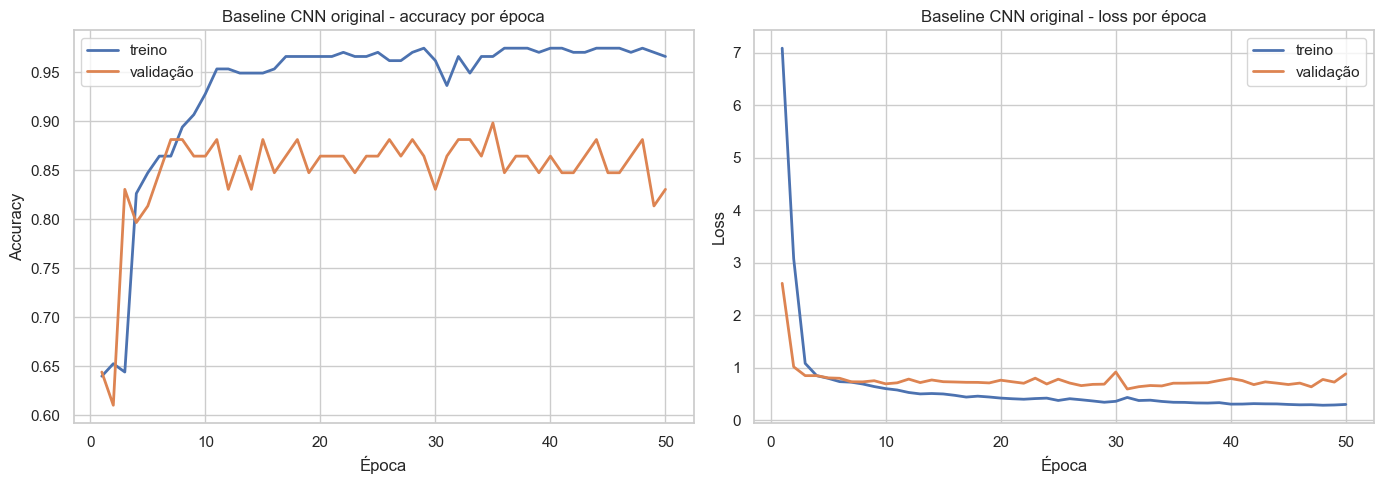

,épocas_treinadas,train_accuracy_final,val_accuracy_final,melhor_val_accuracy,época_melhor_accuracy,melhor_val_loss,época_melhor_loss,gap_treino_validação
0,50,0.9661,0.8305,0.8983,35,0.5927,31,0.1356


In [10]:
epochs = np.arange(1, len(baseline_history_used["accuracy"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, baseline_history_used["accuracy"], label="treino", linewidth=2)
axes[0].plot(epochs, baseline_history_used["val_accuracy"], label="validação", linewidth=2)
axes[0].set_title("Baseline CNN original - accuracy por época")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(epochs, baseline_history_used["loss"], label="treino", linewidth=2)
axes[1].plot(epochs, baseline_history_used["val_loss"], label="validação", linewidth=2)
axes[1].set_title("Baseline CNN original - loss por época")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

train_val_df = pd.DataFrame(
    [
        {
            "épocas_treinadas": baseline_summary["results"]["epochs_trained"],
            "train_accuracy_final": baseline_summary["results"]["final_train_accuracy"],
            "val_accuracy_final": baseline_summary["results"]["final_val_accuracy"],
            "melhor_val_accuracy": baseline_summary["results"]["best_val_accuracy"],
            "época_melhor_accuracy": baseline_summary["results"]["best_val_accuracy_epoch"],
            "melhor_val_loss": baseline_summary["results"]["best_val_loss"],
            "época_melhor_loss": baseline_summary["results"]["best_val_loss_epoch"],
            "gap_treino_validação": baseline_summary["results"]["overfitting_gap_accuracy"],
        }
    ]
)
display(train_val_df)

## 6) Avaliação quantitativa do baseline original

A avaliação quantitativa abaixo compara a CNN do A05 com o baseline MLP da Sprint 2. A ressalva metodológica continua válida:

- a CNN original está documentada com **validação interna**;
- o MLP salvo no projeto apresenta **teste hold-out**.

Mesmo com essa diferença, a comparação é útil para medir a evolução do projeto.

,métrica,valor
0,accuracy,0.8305
1,balanced_accuracy,0.8578
2,precision_weighted,0.8681
3,recall_weighted,0.8305
4,f1_weighted,0.8341
5,auc_roc,0.7155
6,pr_auc,0.5461
7,sensitivity,0.9524
8,specificity,0.7632


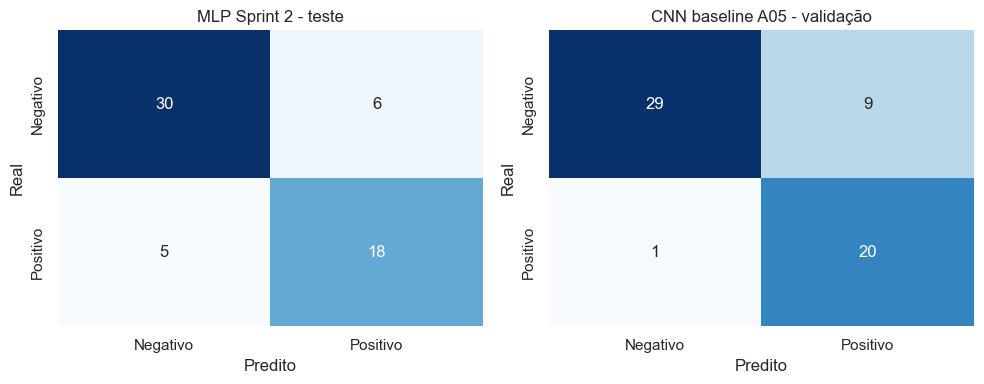

In [11]:
baseline_validation_metrics_df = (
    pd.Series(baseline_summary["validation_metrics"], name="valor")
    .rename_axis("métrica")
    .reset_index()
)
display(baseline_validation_metrics_df)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_confusion(axes[0], mlp_cm, "MLP Sprint 2 - teste")
plot_confusion(axes[1], baseline_cm, "CNN baseline A05 - validação")
plt.tight_layout()
plt.show()

Resultados no teste:
loss: 0.3672
compile_metrics: 0.8136

Relatório de Classificação:
              precision    recall  f1-score   support

    Negativo       0.86      0.83      0.85        36
    Positivo       0.75      0.78      0.77        23

    accuracy                           0.81        59
   macro avg       0.80      0.81      0.81        59
weighted avg       0.82      0.81      0.81        59


,modelo,protocolo,accuracy,loss,sensibilidade_classe_positiva,especificidade_classe_negativa,f1_classe_positiva,delta_accuracy_vs_mlp
0,MLP Sprint 2,teste hold-out,0.813559,0.367241,0.782609,0.833333,0.765957,0.000000
1,CNN baseline A05,validação interna,0.830500,0.881400,0.952400,0.763200,0.800000,0.016941


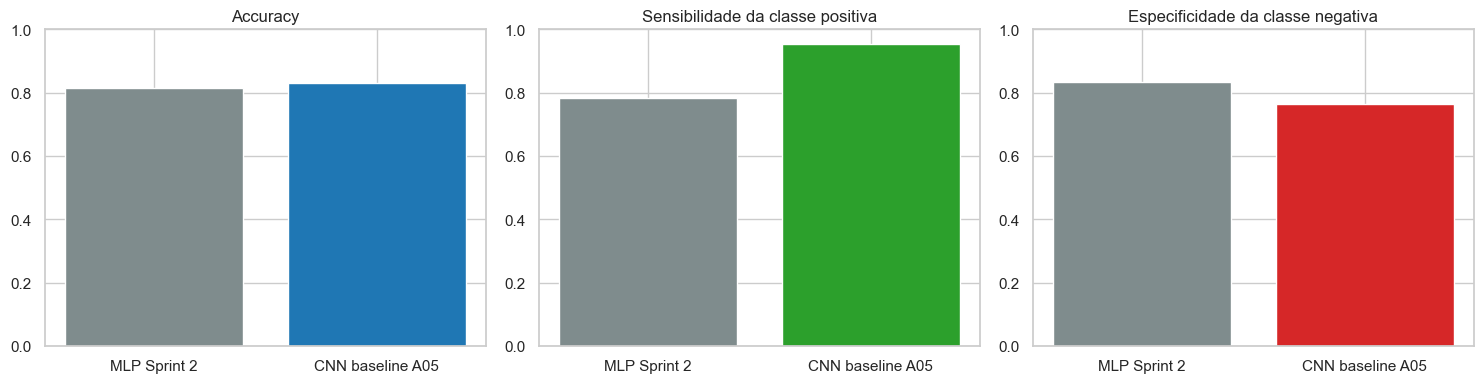

In [12]:
mlp_conf_metrics = metrics_from_confusion(mlp_cm)
cnn_conf_metrics = metrics_from_confusion(baseline_cm)

original_comparison_df = pd.DataFrame(
    [
        {
            "modelo": "MLP Sprint 2",
            "protocolo": "teste hold-out",
            "accuracy": float(mlp_metrics["compile_metrics"]),
            "loss": float(mlp_metrics["loss"]),
            "sensibilidade_classe_positiva": mlp_conf_metrics["recall_positivo"],
            "especificidade_classe_negativa": mlp_conf_metrics["specificity"],
            "f1_classe_positiva": mlp_conf_metrics["f1_positivo"],
        },
        {
            "modelo": "CNN baseline A05",
            "protocolo": "validação interna",
            "accuracy": float(baseline_summary["validation_metrics"]["accuracy"]),
            "loss": float(baseline_summary["results"]["final_val_loss"]),
            "sensibilidade_classe_positiva": float(baseline_summary["validation_metrics"]["sensitivity"]),
            "especificidade_classe_negativa": float(baseline_summary["validation_metrics"]["specificity"]),
            "f1_classe_positiva": cnn_conf_metrics["f1_positivo"],
        },
    ]
)
original_comparison_df["delta_accuracy_vs_mlp"] = original_comparison_df["accuracy"] - float(mlp_metrics["compile_metrics"])
display(original_comparison_df)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].bar(original_comparison_df["modelo"], original_comparison_df["accuracy"], color=["#7f8c8d", "#1f77b4"])
axes[0].set_title("Accuracy")
axes[0].set_ylim(0, 1)

axes[1].bar(original_comparison_df["modelo"], original_comparison_df["sensibilidade_classe_positiva"], color=["#7f8c8d", "#2ca02c"])
axes[1].set_title("Sensibilidade da classe positiva")
axes[1].set_ylim(0, 1)

axes[2].bar(original_comparison_df["modelo"], original_comparison_df["especificidade_classe_negativa"], color=["#7f8c8d", "#d62728"])
axes[2].set_title("Especificidade da classe negativa")
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print(mlp_artifact["test_output"])
print()
print(mlp_artifact["report_text"])

## 7) Ampliação final: CNN simples por sensor

Depois do baseline original, o projeto avançou para uma versão em que a CNN simples é treinada separadamente por sensor. Este bloco amplia a leitura do A05 sem perder o foco no artefato.

,sensor_key,sensor_name,sensor,n_rows_total,n_rows_analysis,n_columns,n_bands,n_images
0,sentinel2,Sentinel2,Sentinel-2,93963765,93963765,13,12,1356
1,landsat89,Landsat 89,Landsat 8/9,105977560,105977560,8,7,1532
2,modis,modis,MODIS,109016100,109016100,8,7,1575


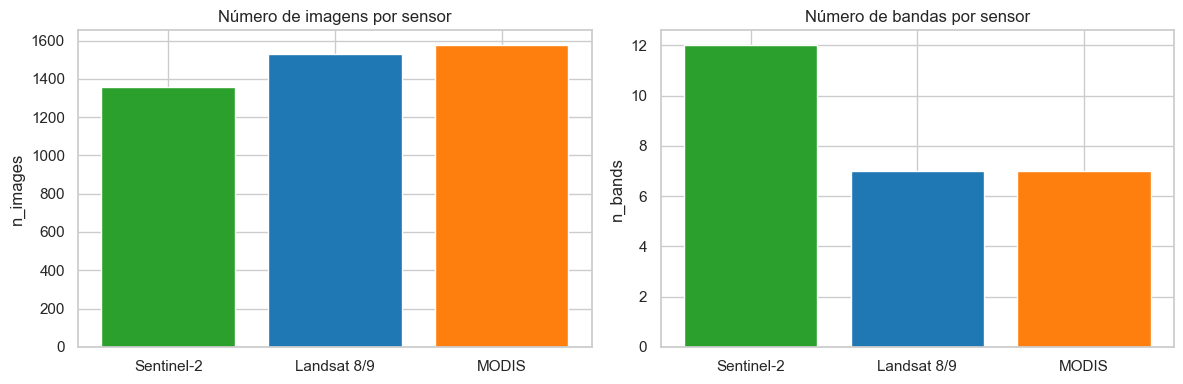

**Hipóteses consolidadas entre sensores**

- O sensor com maior volume de pixels e modis; testar estrategias de balanceamento na etapa integrada.
- Landsat 89 apresentou maior taxa media de faltantes nas bandas; avaliar imputacao/mascara especifica por sensor.
- As medias de NDVI variam entre sensores; testar normalizacao por sensor antes de treinar modelos unificados.

In [13]:
display(compiled_overview_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(compiled_overview_df["sensor"], compiled_overview_df["n_images"], color=["#2ca02c", "#1f77b4", "#ff7f0e"])
axes[0].set_title("Número de imagens por sensor")
axes[0].set_ylabel("n_images")

axes[1].bar(compiled_overview_df["sensor"], compiled_overview_df["n_bands"], color=["#2ca02c", "#1f77b4", "#ff7f0e"])
axes[1].set_title("Número de bandas por sensor")
axes[1].set_ylabel("n_bands")

plt.tight_layout()
plt.show()

display(Markdown("**Hipóteses consolidadas entre sensores**\n\n" + "\n".join(f"- {line}" for line in compiled_hypotheses)))

In [14]:
sensor_context_rows = []
for sensor_key in SENSOR_ORDER:
    bundle = artifacts[sensor_key]
    top_band = bundle["band_summary"].sort_values("std", ascending=False).iloc[0]
    sensor_context_rows.append(
        {
            "sensor": bundle["sensor_name"],
            "n_imagens": bundle["overview"]["n_images"],
            "n_bandas": bundle["overview"]["n_bands"],
            "banda_mais_variável": top_band["band"],
            "std_da_banda": top_band["std"],
            "ndvi_médio": bundle["index_summary"].loc[bundle["index_summary"]["index_name"] == "NDVI", "mean"].iloc[0],
        }
    )
sensor_context_df = pd.DataFrame(sensor_context_rows)
display(sensor_context_df)

,sensor,n_imagens,n_bandas,banda_mais_variável,std_da_banda,ndvi_médio
0,Sentinel-2,1356,12,B11,866.973572,0.466896
1,Landsat 8/9,1532,7,B7,33.219189,-0.086193
2,MODIS,1575,7,B2,6182.770996,0.481508


In [15]:
prep_rows = []
architecture_rows = []

prep_rows.append(
    {
        "modelo": "Baseline original A05",
        "input_shape": tuple(baseline_summary["hyperparameters"]["input_shape"]),
        "n_amostras": baseline_summary["dataset"]["total_samples"],
        "split": f"{baseline_summary['dataset']['train_samples']}/{baseline_summary['dataset']['val_samples']}/-",
    }
)
architecture_rows.append(
    {
        "modelo": "Baseline original A05",
        "total_params": baseline_summary["architecture"]["total_params"],
        "camada_densa": "Flatten -> Dense(128)",
    }
)

for sensor_key in SENSOR_ORDER:
    bundle = artifacts[sensor_key]
    split = bundle["split"]
    prep_rows.append(
        {
            "modelo": bundle["sensor_name"],
            "input_shape": tuple(bundle["metrics"]["input_shape"]),
            "n_amostras": bundle["data_prep"]["n_images_after_label_filter"],
            "split": f"{split['n_train']}/{split['n_val']}/{split['n_test']}",
        }
    )
    architecture_rows.append(
        {
            "modelo": bundle["sensor_name"],
            "total_params": bundle["architecture"]["total_params"],
            "camada_densa": "Flatten -> Dense(128)",
        }
    )

display(pd.DataFrame(prep_rows))
display(pd.DataFrame(architecture_rows))

,modelo,input_shape,n_amostras,split
0,Baseline original A05,"(128, 128, 9)",295,236/59/-
1,Sentinel-2,"(257, 270, 12)",212,148/32/32
2,Landsat 8/9,"(257, 270, 7)",255,178/38/39
3,MODIS,"(257, 270, 7)",430,301/64/65


,modelo,total_params,camada_densa
0,Baseline original A05,8410114,Flatten -> Dense(128)
1,Sentinel-2,35149666,Flatten -> Dense(128)
2,Landsat 8/9,35148226,Flatten -> Dense(128)
3,MODIS,35148226,Flatten -> Dense(128)


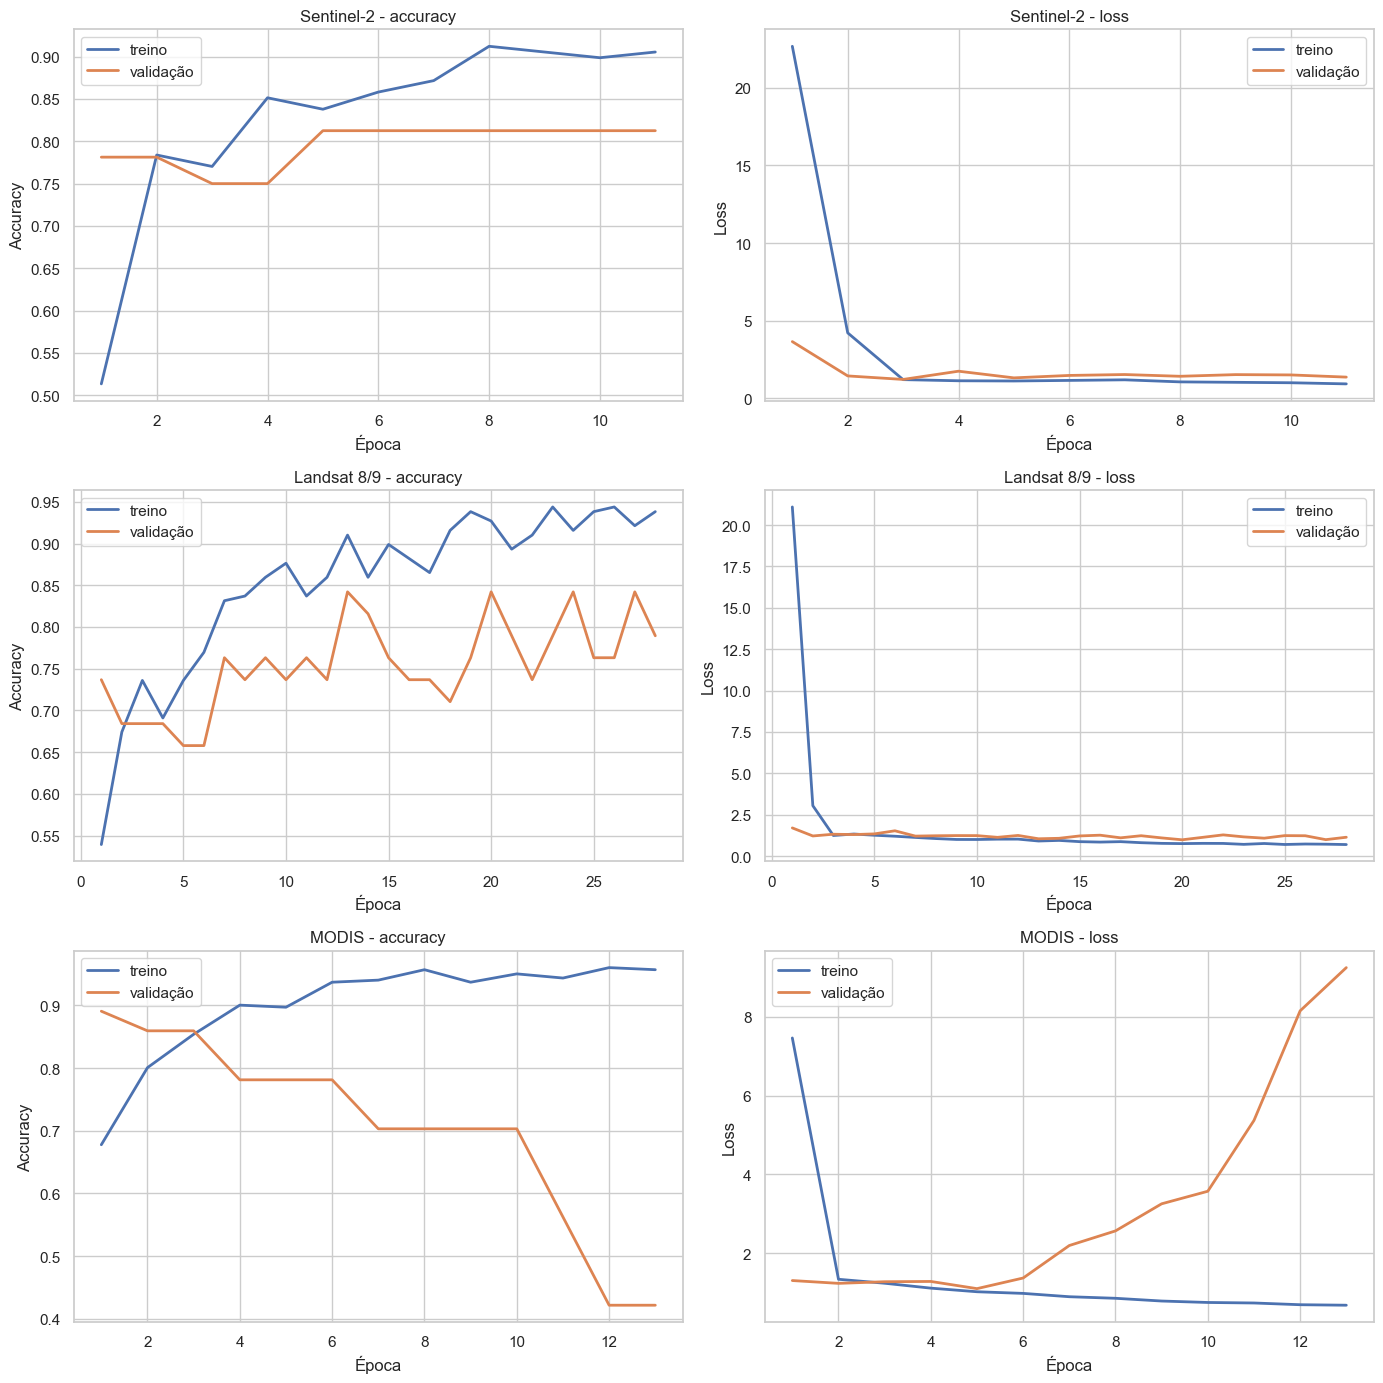

,sensor,cnn_accuracy,cnn_precision,cnn_recall,cnn_f1,cnn_balanced_accuracy,cnn_roc_auc,cnn_pr_auc,generalization_gap,epochs_ran,train_time_s
0,Sentinel-2,0.843750,0.840000,0.954545,0.893617,0.777273,0.877273,0.941475,0.092905,11,92.725890
1,Landsat 8/9,0.846154,0.812500,1.000000,0.896552,0.769231,0.852071,0.849442,0.148729,28,399.078680
2,MODIS,0.769231,0.851064,0.833333,0.842105,0.710784,0.716912,0.859810,0.534936,13,188.968475


In [16]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
for row_idx, sensor_key in enumerate(SENSOR_ORDER):
    bundle = artifacts[sensor_key]
    history = bundle["history"]
    epochs = np.arange(1, len(history["accuracy"]) + 1)

    axes[row_idx, 0].plot(epochs, history["accuracy"], label="treino", linewidth=2)
    axes[row_idx, 0].plot(epochs, history["val_accuracy"], label="validação", linewidth=2)
    axes[row_idx, 0].set_title(f"{bundle['sensor_name']} - accuracy")
    axes[row_idx, 0].set_xlabel("Época")
    axes[row_idx, 0].set_ylabel("Accuracy")
    axes[row_idx, 0].legend()

    axes[row_idx, 1].plot(epochs, history["loss"], label="treino", linewidth=2)
    axes[row_idx, 1].plot(epochs, history["val_loss"], label="validação", linewidth=2)
    axes[row_idx, 1].set_title(f"{bundle['sensor_name']} - loss")
    axes[row_idx, 1].set_xlabel("Época")
    axes[row_idx, 1].set_ylabel("Loss")
    axes[row_idx, 1].legend()

plt.tight_layout()
plt.show()

final_eval_df = final_comparison_df[
    [
        "sensor",
        "cnn_accuracy",
        "cnn_precision",
        "cnn_recall",
        "cnn_f1",
        "cnn_balanced_accuracy",
        "cnn_roc_auc",
        "cnn_pr_auc",
        "generalization_gap",
        "epochs_ran",
        "train_time_s",
    ]
].copy()
display(final_eval_df)

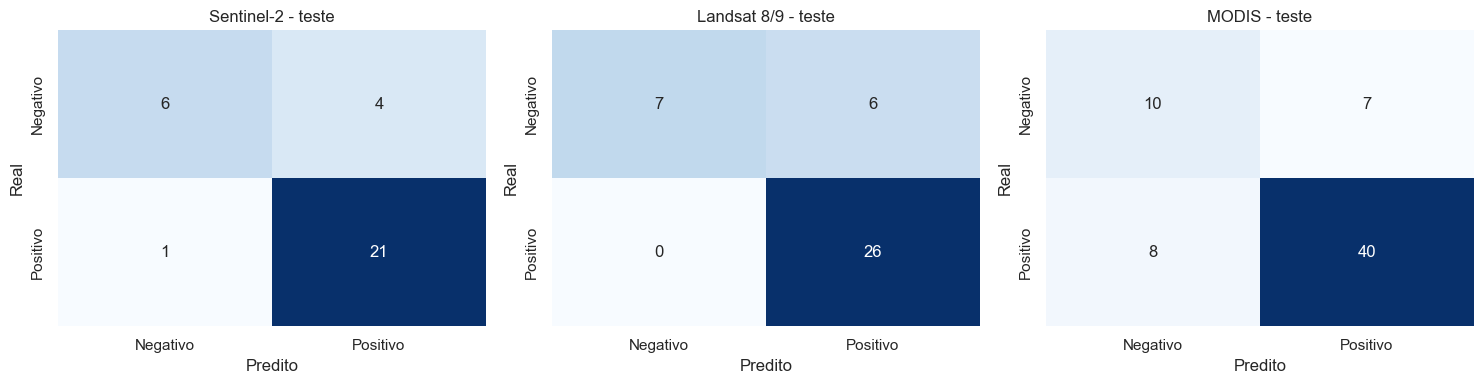

,sensor,cnn_accuracy,cnn_test_loss,mlp_accuracy_sprint2,delta_acc_cnn_minus_mlp
0,Sentinel-2,0.843750,1.254655,0.813559,0.030191
1,Landsat 8/9,0.846154,1.028646,0.813559,0.032595
2,MODIS,0.769231,2.188438,0.813559,-0.044329


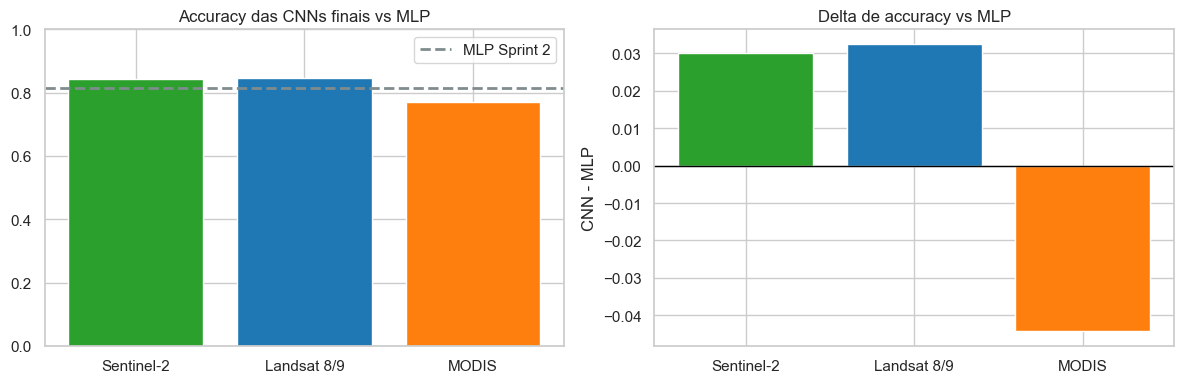

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_confusion(axes[0], artifacts["sentinel2"]["confusion"].values, "Sentinel-2 - teste")
plot_confusion(axes[1], artifacts["landsat89"]["confusion"].values, "Landsat 8/9 - teste")
plot_confusion(axes[2], artifacts["modis"]["confusion"].values, "MODIS - teste")
plt.tight_layout()
plt.show()

final_vs_mlp_df = final_comparison_df[
    [
        "sensor",
        "cnn_accuracy",
        "cnn_test_loss",
        "mlp_accuracy_sprint2",
        "delta_acc_cnn_minus_mlp",
    ]
].copy()
display(final_vs_mlp_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(final_vs_mlp_df["sensor"], final_vs_mlp_df["cnn_accuracy"], color=["#2ca02c", "#1f77b4", "#ff7f0e"])
axes[0].axhline(float(mlp_metrics["compile_metrics"]), linestyle="--", color="#7f8c8d", linewidth=2, label="MLP Sprint 2")
axes[0].set_ylim(0, 1)
axes[0].set_title("Accuracy das CNNs finais vs MLP")
axes[0].legend()

axes[1].bar(final_vs_mlp_df["sensor"], final_vs_mlp_df["delta_acc_cnn_minus_mlp"], color=["#2ca02c", "#1f77b4", "#ff7f0e"])
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Delta de accuracy vs MLP")
axes[1].set_ylabel("CNN - MLP")

plt.tight_layout()
plt.show()

## 8) Análise crítica consolidada

A análise abaixo fecha o artefato de maneira mais direta, destacando desempenho, custo computacional, sinais de sobreajuste e diferenças entre sensores.

In [18]:
critical_rows = [
    {
        "modelo": "MLP Sprint 2",
        "accuracy": float(mlp_metrics["compile_metrics"]),
        "loss": float(mlp_metrics["loss"]),
        "total_params": np.nan,
        "train_time_s": np.nan,
        "protocolo": "teste hold-out",
    },
    {
        "modelo": "CNN baseline A05",
        "accuracy": float(baseline_summary["validation_metrics"]["accuracy"]),
        "loss": float(baseline_summary["results"]["final_val_loss"]),
        "total_params": baseline_summary["architecture"]["total_params"],
        "train_time_s": np.nan,
        "protocolo": "validação interna",
    },
]

for _, row in final_comparison_df.iterrows():
    sensor_key = row["sensor_key"]
    critical_rows.append(
        {
            "modelo": row["sensor"],
            "accuracy": row["cnn_accuracy"],
            "loss": row["cnn_test_loss"],
            "total_params": artifacts[sensor_key]["architecture"]["total_params"],
            "train_time_s": row["train_time_s"],
            "protocolo": "teste por sensor",
        }
    )

critical_df = pd.DataFrame(critical_rows)
display(critical_df)

best_sensor = final_comparison_df.sort_values("cnn_f1", ascending=False).iloc[0]
worst_gap_sensor = final_comparison_df.sort_values("generalization_gap", ascending=False).iloc[0]
modis_gap = final_comparison_df.loc[final_comparison_df["sensor"] == "MODIS", "generalization_gap"].iloc[0]
modis_loss = final_comparison_df.loc[final_comparison_df["sensor"] == "MODIS", "cnn_test_loss"].iloc[0]
modis_delta = final_comparison_df.loc[final_comparison_df["sensor"] == "MODIS", "delta_acc_cnn_minus_mlp"].iloc[0]

modis_hypotheses = artifacts["modis"]["hypotheses"]
sentinel_hypotheses = artifacts["sentinel2"]["hypotheses"]
landsat_hypotheses = artifacts["landsat89"]["hypotheses"]

display(
    Markdown(
        f'''
        **Síntese crítica**

        - O baseline CNN original supera o MLP em `accuracy` ({baseline_summary["validation_metrics"]["accuracy"]:.4f} vs {mlp_metrics["compile_metrics"]:.4f}), mas com uma comparação ainda limitada por protocolos diferentes.
        - Na ampliação final, `Sentinel-2` e `Landsat 8/9` mantêm ganho sobre o MLP, enquanto `MODIS` fica abaixo em `{modis_delta:+.4f}`.
        - O melhor F1 final foi de **{best_sensor["sensor"]}** (`{best_sensor["cnn_f1"]:.4f}`), sugerindo melhor equilíbrio entre precisão e recall.
        - O maior sinal de sobreajuste apareceu em **{worst_gap_sensor["sensor"]}** (`gap={worst_gap_sensor["generalization_gap"]:.4f}`), o que confirma que a CNN simples não generaliza da mesma forma para todos os sensores.
        - O caso do `MODIS` é o mais frágil: além do `gap={modis_gap:.4f}`, o modelo apresenta `loss={modis_loss:.4f}` em teste e hipóteses de alta redundância espectral (`{modis_hypotheses[1]}`), o que enfraquece o ganho da CNN simples.
        - Em `Sentinel-2` e `Landsat 8/9`, as hipóteses exploratórias apontam bandas mais discriminativas e menor fragilidade relativa na generalização (`{sentinel_hypotheses[0]}`; `{landsat_hypotheses[0]}`).
        - O custo computacional aumenta bastante quando a entrada cresce: o baseline original tem cerca de **8,4 milhões** de parâmetros, enquanto as CNNs finais por sensor chegam a **35,1 milhões**, concentrados principalmente em `Flatten -> Dense(128)`.
        - Isso implica um trade-off claro para a próxima sprint: a CNN simples foi suficiente como primeira evolução do MLP, mas o projeto já sinaliza necessidade de arquiteturas mais eficientes e mais regulares para entradas maiores.
        '''
    )
)

display(Markdown("**Leitura textual salva nos outputs finais**\n\n" + "\n".join(f"- {line}" for line in final_analysis_lines)))

,modelo,accuracy,loss,total_params,train_time_s,protocolo
0,MLP Sprint 2,0.813559,0.367241,NaN,NaN,teste hold-out
1,CNN baseline A05,0.830500,0.881400,8410114.0,NaN,validação interna
2,Sentinel-2,0.843750,1.254655,35149666.0,92.725890,teste por sensor
3,Landsat 8/9,0.846154,1.028646,35148226.0,399.078680,teste por sensor
4,MODIS,0.769231,2.188438,35148226.0,188.968475,teste por sensor



        **Síntese crítica**

        - O baseline CNN original supera o MLP em `accuracy` (0.8305 vs 0.8136), mas com uma comparação ainda limitada por protocolos diferentes.
        - Na ampliação final, `Sentinel-2` e `Landsat 8/9` mantêm ganho sobre o MLP, enquanto `MODIS` fica abaixo em `-0.0443`.
        - O melhor F1 final foi de **Landsat 8/9** (`0.8966`), sugerindo melhor equilíbrio entre precisão e recall.
        - O maior sinal de sobreajuste apareceu em **MODIS** (`gap=0.5349`), o que confirma que a CNN simples não generaliza da mesma forma para todos os sensores.
        - O caso do `MODIS` é o mais frágil: além do `gap=0.5349`, o modelo apresenta `loss=2.1884` em teste e hipóteses de alta redundância espectral (`Existe redundancia espectral relevante em B1~B4 (r=1.00); B3~B4 (r=1.00); B1~B3 (r=1.00). Vale testar PCA/selecionador de features.`), o que enfraquece o ganho da CNN simples.
        - Em `Sentinel-2` e `Landsat 8/9`, as hipóteses exploratórias apontam bandas mais discriminativas e menor fragilidade relativa na generalização (`Bandas com maior variabilidade (B11, B12, B9) podem carregar maior poder discriminativo para classificacao.`; `Bandas com maior variabilidade (B7, B5, B4) podem carregar maior poder discriminativo para classificacao.`).
        - O custo computacional aumenta bastante quando a entrada cresce: o baseline original tem cerca de **8,4 milhões** de parâmetros, enquanto as CNNs finais por sensor chegam a **35,1 milhões**, concentrados principalmente em `Flatten -> Dense(128)`.
        - Isso implica um trade-off claro para a próxima sprint: a CNN simples foi suficiente como primeira evolução do MLP, mas o projeto já sinaliza necessidade de arquiteturas mais eficientes e mais regulares para entradas maiores.
        

**Leitura textual salva nos outputs finais**

- Sentinel-2: indicio de overfitting (gap=0.0929).
- Sentinel-2: ganho de +0.0302 em acuracia vs MLP Sprint 2.
- Landsat 8/9: indicio de overfitting (gap=0.1487).
- Landsat 8/9: ganho de +0.0326 em acuracia vs MLP Sprint 2.
- MODIS: indicio de overfitting (gap=0.5349).
- MODIS: queda de -0.0443 em acuracia vs MLP Sprint 2.
- Melhor F1: Landsat 8/9 (0.8966).
- Limitacao: o baseline MLP salvo no projeto possui poucas metricas detalhadas; a comparacao principal ficou concentrada em acuracia/loss.

## 9) Checklist de entrega

A tabela abaixo amarra o barema do artefato com as seções efetivamente atendidas neste notebook.

In [19]:
checklist_df = pd.DataFrame(
    [
        {"item": "(1) Preparação dos dados para CNN", "evidência": "Seção 3", "status": "Atendido"},
        {"item": "(2) Implementação da arquitetura CNN", "evidência": "Seção 4", "status": "Atendido"},
        {"item": "(3) Treinamento e validação do modelo", "evidência": "Seção 5", "status": "Atendido"},
        {"item": "(4) Avaliação quantitativa de desempenho", "evidência": "Seções 6 e 7", "status": "Atendido"},
        {"item": "(5) Análise crítica dos resultados", "evidência": "Seção 8", "status": "Atendido"},
    ]
)
display(checklist_df)

files_df = pd.DataFrame(
    [
        {"arquivo": "artefatos/a05_cnn_simples/a05_cnn_simples.ipynb", "papel": "Notebook oficial do artefato."},
        {"arquivo": "artefatos/a05_cnn_simples/README.md", "papel": "Guia do artefato e das fontes incorporadas."},
        {"arquivo": "scripts/generate_a05_artifact_notebook.py", "papel": "Gerador reproduzível do notebook."},
        {"arquivo": "scripts/render_notebook_outputs.py", "papel": "Renderizador local que grava os outputs no .ipynb."},
    ]
)
display(files_df)

,item,evidência,status
0,(1) Preparação dos dados para CNN,Seção 3,Atendido
1,(2) Implementação da arquitetura CNN,Seção 4,Atendido
2,(3) Treinamento e validação do modelo,Seção 5,Atendido
3,(4) Avaliação quantitativa de desempenho,Seções 6 e 7,Atendido
4,(5) Análise crítica dos resultados,Seção 8,Atendido


,arquivo,papel
0,artefatos/a05_cnn_simples/a05_cnn_simples.ipynb,Notebook oficial do artefato.
1,artefatos/a05_cnn_simples/README.md,Guia do artefato e das fontes incorporadas.
2,scripts/generate_a05_artifact_notebook.py,Gerador reproduzível do notebook.
3,scripts/render_notebook_outputs.py,Renderizador local que grava os outputs no .ip...
